<div style="background:linear-gradient(135deg,#0D2B55 0%,#1F497D 60%,#2E86C1 100%);padding:28px 32px;border-radius:10px;margin-bottom:18px"><h1 style="color:white;margin:0 0 6px 0;font-size:1.9em">Financial Risk Management and Engineering — Session 1: Course Overview & the Six Types of Financial Risk</h1><p style="color:#BDC3C7;margin:0;font-size:1.0em">Aarhus University Summer School · Summer 2026</p><p style="color:#85C1E9;margin:8px 0 0 0;font-size:0.9em">The six risk categories · real-data workflow · returns, volatility, drawdown, fat tails</p></div>

This notebook is the hands-on companion to Session 1. We pull five years of real market data and use it to *see* each of the six financial-risk categories, then practise the data-acquisition workflow that every assignment in the portfolio exam depends on.

*Reference: Hull (2023) Ch. 1; Jorion (2010) Financial Risk Manager Handbook, Ch. 1.*

<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Getting Started — Python & VS Code</span><br><span style="color:#BDC3C7;font-size:0.93em">A 10-minute on-ramp · skip ahead to Block 0 if you already code in Python</span></div>

In [1]:
!pip install yfinance pandas numpy matplotlib seaborn scipy \
             statsmodels scikit-learn PyPortfolioOpt arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.4/930.4 kB 34.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 51.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 25.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.1/935.1 kB 40.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 55.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15/15 [arch]2m14/15 [arch]nce]se]


> **Full setup guide:** the *Getting Started: VS Code & Python* primer (distributed before Session 1) covers all of this in detail, plus Jupyter tips and a troubleshooting table. This section is the short version.

This class mixes complete beginners with experienced coders. If Python is new to you, this section gets you from zero to a running notebook. **You do not need any prior programming.**

### 1 · Install the tools (once)
- **Python** — install [Anaconda](https://www.anaconda.com/download). It bundles Python *and* almost every package we use (numpy, pandas, scipy, matplotlib, statsmodels, scikit-learn).
- **An editor** — [VS Code](https://code.visualstudio.com), the course standard. It opens Jupyter notebooks directly and pairs with two free AI helpers: GitHub Copilot (student pack) and Anaconda Assistant, the AI built into Anaconda's Jupyter tools.
- On first open, accept the prompt to install the **Python** and **Jupyter** extensions.
- No installs allowed on your machine? [Google Colab](https://colab.research.google.com) runs this notebook in the browser for free — just upload the `.ipynb`.

### 2 · Open this notebook
1. **File ▸ Open Folder** and choose the course folder (keep all your work in one place).
2. Open this `.ipynb` file. Top-right, **select the kernel** = *Anaconda (base)* / *Python 3*.
3. Click any code cell and press **Shift+Enter** to run it — output appears underneath.

### 3 · A couple of extras
Anaconda has most packages, but a few are installed on top. Run this **once** in a terminal (or put a `!` in front to run it inside a cell):

```bash
pip install yfinance arch PyPortfolioOpt
```

<div style="border-left:5px solid #2E86C1;background:#0A1E33;padding:8px 14px;border-radius:0 5px 5px 0;margin:6px 0 2px 0"><b style="color:#7BC8F6">Main packages we use all term</b> · <b>numpy</b> (np) arrays/math · <b>pandas</b> (pd) tables &amp; time series · <b>matplotlib.pyplot</b> (plt) &amp; <b>seaborn</b> (sns) charts · <b>scipy.stats</b> distributions/tests · <b>statsmodels</b> regression · <b>arch</b> GARCH volatility · <b>scikit-learn</b> ML · <b>yfinance</b> (yf) free market data · <b>PyPortfolioOpt</b> optimisation. The short names in brackets are the conventional aliases — use them.</div>

**Environment check** — run the cell below. Every line should print a version number. Anything marked `NOT INSTALLED` tells you exactly what to `pip install`.

In [2]:
import importlib, sys
print('Python', sys.version.split()[0], '\n')
for pkg in ['numpy','pandas','matplotlib','scipy','statsmodels',
            'yfinance','arch','sklearn','seaborn']:
    try:
        m = importlib.import_module(pkg)
        print(f'  {pkg:13s} {getattr(m, "__version__", "ok")}')
    except Exception:
        print(f'  {pkg:13s} NOT INSTALLED  ->  pip install {pkg}')

Python 3.13.9 

  numpy         2.3.5
  pandas        2.3.3
  matplotlib    3.10.6
  scipy         1.16.3
  statsmodels   0.14.5
  yfinance      1.5.1
  arch          8.0.0
  sklearn       1.7.2
  seaborn       0.13.2


<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Block 0 — Toolkit & Data</span><br><span style="color:#BDC3C7;font-size:0.93em">Window: 2021-07-01 to 2026-07-01</span></div>

In [1]:
import warnings; warnings.filterwarnings('ignore')
import os, time
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from scipy.optimize import minimize

try:
    import seaborn as sns
except Exception:
    sns = None
from IPython.display import display

plt.rcParams.update({
    'figure.figsize': (13, 5), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 12,
})
np.random.seed(42)

# ── Analysis period: last 5 years ──────────────────────────────────────────
START, END = '2021-07-01', '2026-07-01'
RF_ANNUAL = 0.04
RF_DAILY  = RF_ANNUAL / 252

TICKERS = ['SPY', 'AAPL', 'JPM', 'XOM', 'JNJ', 'NVDA', 'KO', 'GLD', 'TLT', 'LQD', 'HYG']
CACHE = os.path.join('notebook_data', 'Session_01_data.csv')
os.makedirs('notebook_data', exist_ok=True)

def load_prices(tickers=TICKERS, cache=CACHE, ohlcv=False):
    """Load adjusted prices, caching a CSV snapshot for reproducibility."""
    if os.path.exists(cache):
        df = pd.read_csv(cache, index_col=0, parse_dates=True, header=[0, 1] if ohlcv else 0)
        print(f'Loaded snapshot: {cache}  ({df.shape[0]} rows)')
        return df
    last = None
    for attempt in range(3):
        try:
            raw = yf.download(tickers, start=START, end=END, auto_adjust=True, progress=False)
            if raw is not None and not raw.empty:
                df = raw if False else raw['Close']
                df = df.dropna(how='all')
                df.to_csv(cache)
                print(f'Downloaded {len(tickers)} tickers {START}–{END} '
                      f'({df.shape[0]} rows); snapshot saved to {cache}')
                return df
        except Exception as e:
            last = e
        time.sleep(3 * (attempt + 1))
    raise RuntimeError(f'yfinance download failed after retries: {last}')


In [2]:
prices = load_prices()
prices = prices[TICKERS].dropna()
rets = np.log(prices / prices.shift(1)).dropna()
print('Assets:', list(prices.columns))
print('Window:', rets.index[0].date(), 'to', rets.index[-1].date(), '|', len(rets), 'days')
display(prices.tail(3).round(2))

Downloaded 11 tickers 2021-07-01–2026-07-01 (1254 rows); snapshot saved to notebook_data/Session_01_data.csv
Assets: ['SPY', 'AAPL', 'JPM', 'XOM', 'JNJ', 'NVDA', 'KO', 'GLD', 'TLT', 'LQD', 'HYG']
Window: 2021-07-02 to 2026-06-30 | 1253 days


Ticker,SPY,AAPL,JPM,XOM,JNJ,NVDA,KO,GLD,TLT,LQD,HYG
Date,,,,,,,,,,,
2026-06-26,728.99,283.78,329.05,136.54,254.66,192.53,82.63,373.63,87.04,109.12,79.46
2026-06-29,741.00,281.74,329.39,136.06,258.51,194.97,82.65,368.58,87.13,109.32,79.64
2026-06-30,746.77,289.36,327.33,136.72,253.97,200.09,81.27,368.38,86.10,108.69,79.60


<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Block 1 — Returns, Volatility & Drawdown</span><br><span style="color:#BDC3C7;font-size:0.93em">The measurement primitives behind every risk metric</span></div>

<div style="border-left:5px solid #2E86C1;background:#0A1E33;padding:8px 14px;border-radius:0 5px 5px 0;margin:6px 0 2px 0"><b style="color:#7BC8F6">Definitions</b> · Log return $r_t=\ln(P_t/P_{t-1})$; annualised mean $=252\,\bar r$; annualised volatility $=\sqrt{252}\,\sigma$. Risk is the *uncertainty* in these — not their level.</div>

In [ ]:
summary = pd.DataFrame({
    'Ann. return': rets.mean()*252,#252=number of trading days in a year 
    'Ann. vol':    rets.std()*np.sqrt(252),
})
summary['Sharpe (rf=4%)'] = (summary['Ann. return']-RF_ANNUAL)/summary['Ann. vol']
display(summary.sort_values('Ann. vol').round(3))

,Ann. return,Ann. vol,Sharpe (rf=4%)
Ticker,,,
HYG,0.035,0.075,-0.070
LQD,-0.004,0.087,-0.504
TLT,-0.070,0.158,-0.695
KO,0.112,0.162,0.444
JNJ,0.114,0.171,0.432
SPY,0.124,0.172,0.492
GLD,0.160,0.184,0.653
JPM,0.173,0.245,0.544
XOM,0.192,0.267,0.568


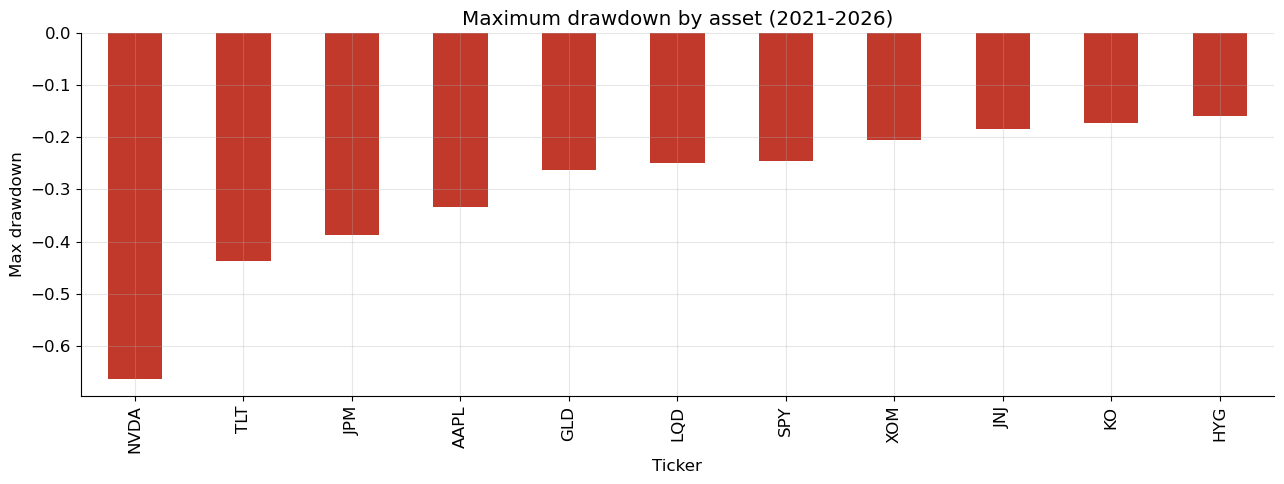

Worst drawdown: NVDA -66.3%


In [4]:
# Maximum drawdown of each asset
def max_drawdown(series):
    cum = (1+series.pct_change().fillna(0)).cumprod()
    return (cum/cum.cummax()-1).min()
dd = prices.apply(max_drawdown).sort_values()
ax = dd.plot(kind='bar', color='#C0392B', title='Maximum drawdown by asset (2021-2026)')
ax.set_ylabel('Max drawdown'); plt.tight_layout(); plt.show()
print('Worst drawdown:', dd.idxmin(), f'{dd.min():.1%}')

<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Block 2 — Fat Tails</span><br><span style="color:#BDC3C7;font-size:0.93em">Why the normal distribution understates risk</span></div>

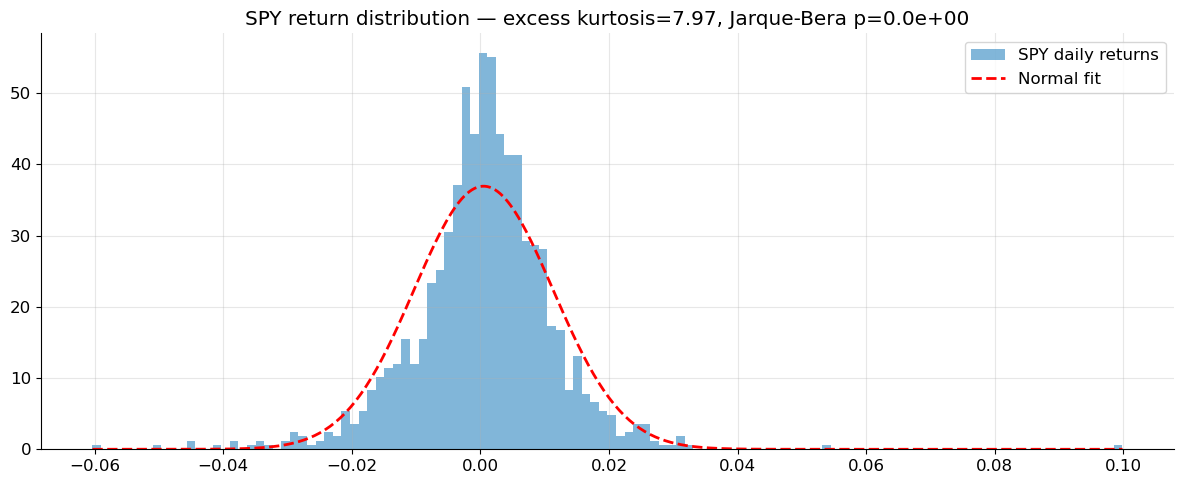

Skew=0.14  Excess kurtosis=7.97  (normal=0)

5 worst SPY days:
Date
2025-04-04   -6.03
2025-04-03   -5.05
2025-04-10   -4.48
2022-09-13   -4.45
2022-05-18   -4.11


In [5]:
spy = rets['SPY']
jb_stat, jb_p = stats.jarque_bera(spy)
fig, ax = plt.subplots(figsize=(12,5))
ax.hist(spy, bins=120, density=True, alpha=0.6, color='#2E86C1', label='SPY daily returns')
x = np.linspace(spy.min(), spy.max(), 400)
ax.plot(x, stats.norm.pdf(x, spy.mean(), spy.std()), 'r--', lw=2, label='Normal fit')
ax.set_title(f'SPY return distribution — excess kurtosis={spy.kurtosis():.2f}, '
             f'Jarque-Bera p={jb_p:.1e}'); ax.legend(); plt.tight_layout(); plt.show()
print(f'Skew={spy.skew():.2f}  Excess kurtosis={spy.kurtosis():.2f}  (normal=0)')
worst = spy.nsmallest(5)
print('\n5 worst SPY days:'); print((worst*100).round(2).to_string())

<div style="border-left:5px solid #27AE60;background:#0A2A1A;padding:8px 14px;border-radius:0 5px 5px 0;margin:4px 0"><b style="color:#58D68D">&#128161;</b> Daily equity returns are <b>leptokurtic</b> (fat-tailed): extreme moves happen far more often than a normal distribution predicts. Every VaR/ES model in this course must reckon with this — it is the single most important empirical fact in market risk.</div>

<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Block 3 — The Six Risk Categories in the Data</span><br><span style="color:#BDC3C7;font-size:0.93em">Market · Credit · Liquidity · Operational · Systemic · ESG/Climate</span></div>

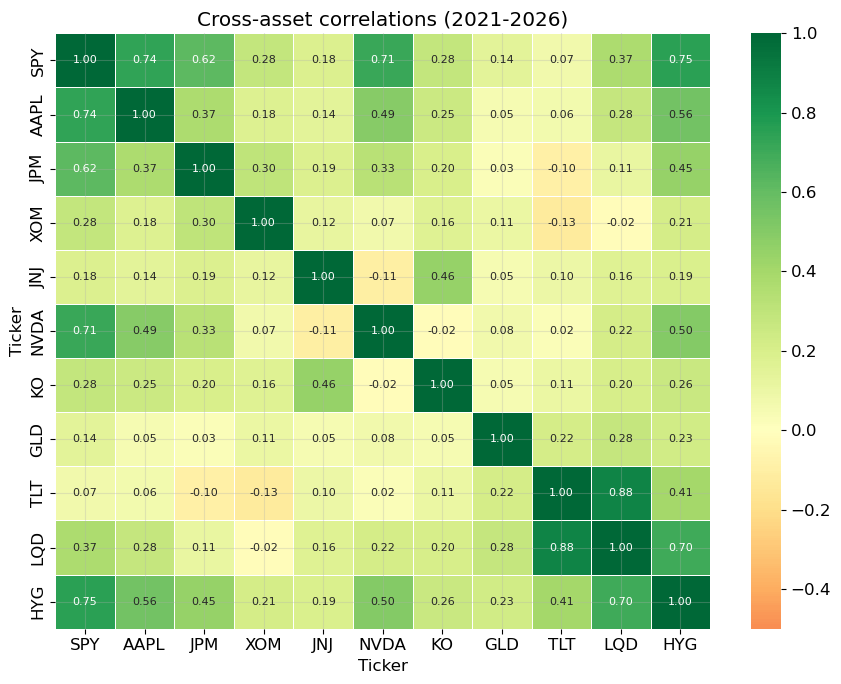

In [6]:
# Correlation heatmap — diversification is the core risk-management lever
corr = rets.corr()
fig, ax = plt.subplots(figsize=(9,7))
if sns is not None:
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0, vmin=-0.5, vmax=1,
                linewidths=.4, ax=ax, annot_kws={'size':8})
else:
    im=ax.imshow(corr, cmap='RdYlGn', vmin=-0.5, vmax=1)
    ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45)
    ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns); fig.colorbar(im)
ax.set_title('Cross-asset correlations (2021-2026)'); plt.tight_layout(); plt.show()

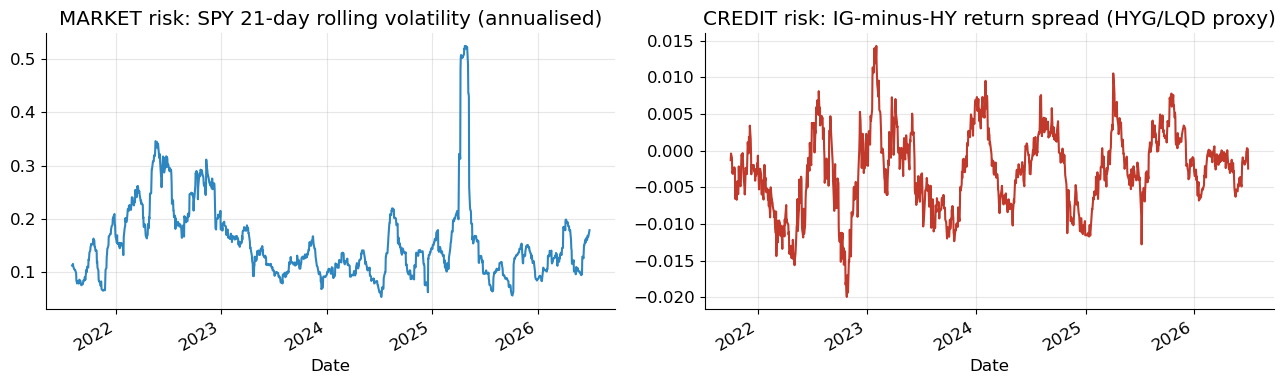

In [7]:
# MARKET risk = volatility; CREDIT risk = HY-IG spread proxy (HYG vs LQD)
credit_proxy = (rets['LQD'] - rets['HYG']).rolling(63).mean()*np.sqrt(252)
fig, axes = plt.subplots(1,2, figsize=(13,4))
rets['SPY'].rolling(21).std().mul(np.sqrt(252)).plot(ax=axes[0], color='#2E86C1')
axes[0].set_title('MARKET risk: SPY 21-day rolling volatility (annualised)')
credit_proxy.plot(ax=axes[1], color='#C0392B')
axes[1].set_title('CREDIT risk: IG-minus-HY return spread (HYG/LQD proxy)')
plt.tight_layout(); plt.show()

| Category | How we see it here | Course session |
|---|---|---|
| **Market** | SPY rolling volatility; fat tails | S2–S4 |
| **Credit** | HYG vs LQD spread widening in stress | S5–S6 |
| **Liquidity** | trading volume / Amihud (S7); spreads blow out in crises | S7 |
| **Operational** | not in price data — modelled from loss events | S7 |
| **Systemic** | correlations spike toward 1 in the 2022 drawdown | S12 |
| **ESG/Climate** | not fully priced; rating providers disagree | S10, S12 |

<div style="border-left:5px solid #C0392B;background:#1C0505;padding:8px 14px;border-radius:0 5px 5px 0;margin:4px 0"><b style="color:#E74C3C">&#9888;&#65039;</b> Notice the correlations: in calm times diversification looks strong, but in the 2020 and 2022 sell-offs equity correlations rose toward 1. <b>Diversification fades exactly when you need it</b> — the systemic-risk lesson of every crisis (LTCM 1998, GFC 2008).</div>

<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Block 4 — Your Exam Data Workflow</span><br><span style="color:#BDC3C7;font-size:0.93em">Reproducibility is graded — pin the data, save a snapshot</span></div>

In [8]:
# The reproducible pattern every assignment uses: pin dates, download once, snapshot to CSV.
snapshot = prices[['SPY','AAPL','JPM']].copy()
snapshot.to_csv('notebook_data/Session_01_exam_demo_snapshot.csv')
print('Saved a reproducible snapshot:', snapshot.shape)
print('Rule of thumb: your narrative numbers must match this saved file exactly.')

Saved a reproducible snapshot: (1254, 3)
Rule of thumb: your narrative numbers must match this saved file exactly.


<div style="border-left:5px solid #D4A017;background:#1C1400;padding:8px 14px;border-radius:0 5px 5px 0;margin:4px 0"><b style="color:#F0B429">&#128172;</b> <b>Exam data rules.</b> Stock 1 starts with your first-name initial, Stock 2 with your last-name initial, Stock 3 in a different sector. All three trade in ONE market bloc, benchmarked to that bloc's index (North America &rarr; ^GSPC; Europe &rarr; ^STOXX). Use &ge;3 years of daily data, pin an end-date, and save a CSV snapshot.</div>

<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Your Turn — Build Your Own Risk Picture</span><br><span style="color:#BDC3C7;font-size:0.93em">Parts A–E · use your own three stocks + bloc index · <b>Part A in class today — Parts B–E are tonight’s homework</b></span></div>

## Part A — Universe & data
Pick your three exam stocks + your bloc index. Download 2021-07-01 to 2026-07-01 and save a CSV snapshot.

## Part B — Returns, volatility, drawdown
Compute annualised mean, volatility, Sharpe and maximum drawdown for each.

## Part C — Fat tails
Plot one stock's return histogram vs a normal fit; report skew, excess kurtosis, Jarque-Bera.

## Part D — Risk categories
For your worst 5 days, state which of the six risk categories best explains each.

## Part E — Reflection
Which category worries you most for your portfolio, and which course session addresses it?

In [ ]:
# Part A — YOUR CODE HERE
MY_TICKERS = ['AAPL', 'PFE', 'XOM']            # Apple (technology) · Pfizer (Healthcare) · Exxon (Energy)
BLOC_INDEX = '^GSPC'                            # S&P 500 (North America)

MY_START = '2021-07-01'                         # <-- start date
MY_END   = '2026-07-01'                         # <-- end date
CACHE    = 'notebook_data/my_portfolio.csv'

# Download once (using MY_START / MY_END), then reuse the CSV snapshot
if os.path.exists(CACHE):
    my_prices = pd.read_csv(CACHE, index_col=0, parse_dates=True)
    print(f'Loaded snapshot: {CACHE}')
else:
    raw = yf.download(MY_TICKERS + [BLOC_INDEX],
                      start=MY_START, end=MY_END,        # <-- dates used here
                      auto_adjust=True, progress=False)
    my_prices = raw['Close']
    my_prices.to_csv(CACHE)
    print(f'Downloaded {MY_START} -> {MY_END} from Yahoo Finance, saved {CACHE}')

# Order columns, drop missing rows, compute daily log returns
my_prices = my_prices[MY_TICKERS + [BLOC_INDEX]].dropna()
my_rets   = np.log(my_prices / my_prices.shift(1)).dropna()

# Verify >= 3 years of daily data
n_years = (my_prices.index[-1] - my_prices.index[0]).days / 365.25
print(f'Requested window : {MY_START} -> {MY_END}')
print(f'Actual window    : {my_prices.index[0].date()} -> {my_prices.index[-1].date()}')
print(f'Rows             : {len(my_prices)} trading days  (~{n_years:.1f} years)')
assert n_years >= 3, 'Need at least 3 years of data!'

print('Assets :', list(my_prices.columns))
display(my_prices.tail(3).round(2))


In [11]:
# Part B — YOUR CODE HERE


In [12]:
# Part C — YOUR CODE HERE


In [13]:
# Part D & E — YOUR CODE HERE (markdown reflection below)


<sub>Yuriy Zabolotnyuk · Sprott School of Business · Carleton University</sub>